# YouTube Comment Sentiment Analysis on MKBHD Galaxy Ring Review
This project analyzes YouTube comments from a Marques Brownlee review video using NLP techniques such as preprocessing, word frequency analysis, sentiment classification, and topic modeling.

In [ ]:
!pip install google-api-python-client

In [ ]:
import googleapiclient.discovery
import googleapiclient.errors
import pandas as pd
import os
from googleapiclient.discovery import build

In [ ]:
#Defining API key and initialize YouTube API
api_key = os.getenv("YOUTUBE_API_KEY")
youtube = googleapiclient.discovery.build("youtube", "v3", developerKey=api_key)

In [ ]:
#Defining the video ID (extracted from the YouTube link)
video_id = "tYUC_Ni3lb4"

In [ ]:
#Function to get comments
def get_comments(video_id, max_results=100):
    comments = []
    try:
        response = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=max_results,
            textFormat="plainText"
        ).execute()

        while response:
            for item in response['items']:
                comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
                comments.append(comment)
            if 'nextPageToken' in response:
                response = youtube.commentThreads().list(
                    part="snippet",
                    videoId=video_id,
                    maxResults=max_results,
                    pageToken=response['nextPageToken'],
                    textFormat="plainText"
                ).execute()
            else:
                break
    except googleapiclient.errors.HttpError as e:
        print(f"An error occurred: {e}")
    return comments

In [ ]:
#Get comments
comments = get_comments(video_id)


In [ ]:
#Save comments to a DataFrame
df = pd.DataFrame(comments, columns=["comment"])
print(df.head())

                                                                                                                                                                                                                                                                                                                                                           comment
0                                                                                                                                                                                                                                                                                                                                          0:11 Existential fucks?
1                                                                                                                                                                                                                                                                                                 

In [ ]:
#Saving to CSV
df.to_csv("youtube_comments.csv", index=False)

In [ ]:
!pip install fastbook

In [ ]:
import fastbook
fastbook.setup_book()

In [ ]:
from fastbook import *
from fastai.vision.all import *
import pandas as pd

In [ ]:
#Loading comments
df = pd.read_csv("youtube_comments.csv")

In [ ]:
#Check for missing values
missing_values_count = df['comment'].isna().sum()

In [ ]:
print(f"Number of missing values in 'comment' column: {missing_values_count}")

Number of missing values in 'comment' column: 1


In [ ]:
#Impute missing values with a placeholder string
df['comment'] = df['comment'].fillna('No comment').astype(str)

In [ ]:
#Checking again to confirm there are no missing values
missing_values_count_after = df['comment'].isna().sum()

In [ ]:
print(f"Number of missing values in 'comment' column after imputation: {missing_values_count_after}")


Number of missing values in 'comment' column after imputation: 0


In [ ]:
!pip install nltk

In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import string

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
translator = str.maketrans('', '', string.punctuation)

In [ ]:
def preprocess_text(text):
    text = text.translate(translator)  #Removeing punctuations
    return text

In [ ]:
df['cleaned_comment'] = df['comment'].apply(preprocess_text)


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
#Creating a word cloud
all_comments = ' '.join(df['cleaned_comment'])

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_comments)

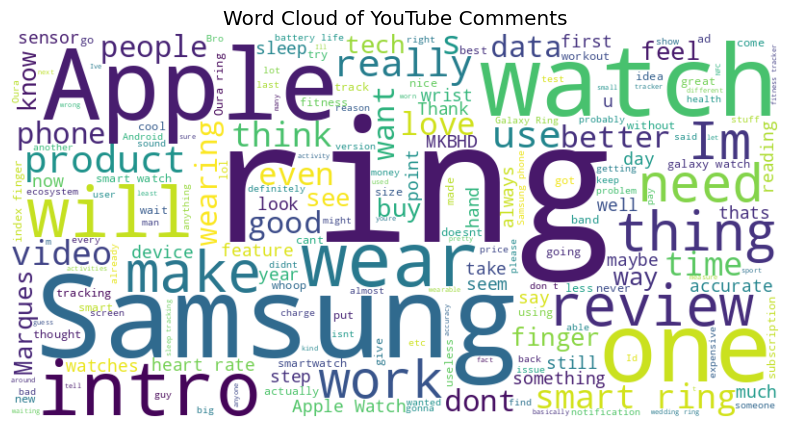

In [ ]:
#Displaying the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of YouTube Comments')
plt.show()

In [ ]:
#Finding the word with the highest count
word_counts = Counter(all_comments.split())

In [ ]:
most_common_words = word_counts.most_common(10)

In [ ]:
print("Most common words:", most_common_words)

Most common words: [('the', 2647), ('a', 1941), ('to', 1619), ('I', 1381), ('it', 1296), ('and', 1170), ('ring', 1147), ('is', 930), ('for', 899), ('you', 854)]


In [ ]:
#Here we label comments containing 'good' as positive and others as negative for illustration.
df['label'] = df['comment'].apply(lambda x: 1 if 'good' in x.lower() else 0)

In [ ]:
from fastai.text.all import *

In [ ]:
#Createing a DataLoaders object for language model
dls_lm = TextDataLoaders.from_df(df, text_col='cleaned_comment', is_lm=True, valid_pct=0.1)

/usr/local/lib/python3.10/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


In [ ]:
#Finetune the language model
learn = language_model_learner(dls_lm, AWD_LSTM, drop_mult=0.5)


SuggestedLRs(valley=0.005248074419796467)

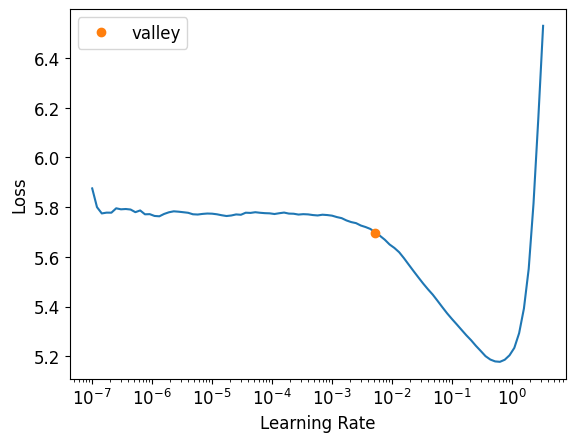

In [ ]:
#Finding the best learning rate
learn.lr_find()

In [ ]:
#Using the suggested learning rate from the plot, which is  2.51e-3
best_lr =  2.51e-3

In [ ]:
#Fine-tune the language model
learn.fit_one_cycle(1, best_lr)


epoch,train_loss,valid_loss,time
0,0.122269,0.187108,00:05


In [ ]:
learn.save_encoder('fine_tuned_enc')

In [ ]:
#Creating a DataLoaders object for classification
dls_clas = TextDataLoaders.from_df(df, text_col='cleaned_comment', label_col='label', is_lm=False, valid_pct=0.1)


/usr/local/lib/python3.10/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


In [ ]:
#Fine-tuning the classifier with early stopping
learn = text_classifier_learner(dls_clas, AWD_LSTM, drop_mult=0.5)

In [ ]:
learn.load_encoder('fine_tuned_enc')


In [ ]:
#Useing EarlyStoppingCallback to stop training if validation loss doesn't improve for 3 epochs
callbacks = [EarlyStoppingCallback(monitor='valid_loss', patience=3)]

SuggestedLRs(valley=0.0020892962347716093)

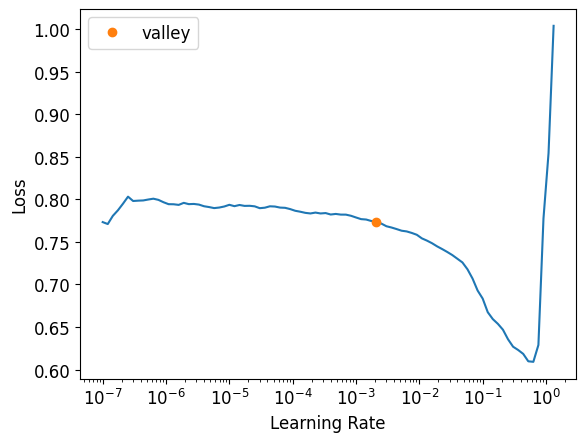

In [ ]:
#Finding the best learning rate for the classifier
learn.lr_find()

In [ ]:
#Using the suggested learning rate from the plot, which is 3.16e-3
best_lr_clas =  3.16e-3

In [ ]:
#Training the classifier
learn.fit_one_cycle(10, best_lr_clas, cbs=callbacks)

epoch,train_loss,valid_loss,time
0,0.733848,0.670314,00:06
1,0.644986,0.433280,00:04
2,0.432174,0.208506,00:04
3,0.266165,0.162455,00:05
4,0.181868,0.182203,00:04
5,0.135334,0.179006,00:04
6,0.113910,0.177441,00:05


No improvement since epoch 3: early stopping


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

In [ ]:
#Evaluating on the validation set
val_preds, val_targets = learn.get_preds()


In [ ]:
accuracy = accuracy_score(val_targets, val_preds.argmax(dim=1))
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.97


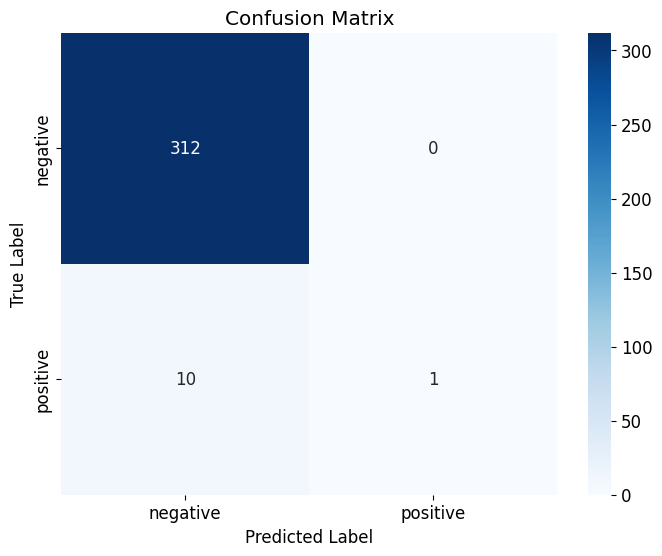

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(val_targets, val_preds.argmax(dim=1))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Make predictions on the entire dataset
dl = learn.dls.test_dl(df['cleaned_comment'])

In [ ]:
preds, _ = learn.get_preds(dl=dl)

In [ ]:
df['predictions'] = preds.argmax(dim=1)

In [ ]:
df['predictions'] = df['predictions'].apply(lambda x: 'positive' if x == 1 else 'negative')


In [ ]:
#Saving classified comments
df.to_csv("classified_comments.csv", index=False)

In [ ]:
#Displaying the first few classified comments
print("Classified Comments:")
print(df[['comment', 'predictions']].head())

Classified Comments:
                                                                                                                                                                                                                                                                                                                                                           comment  \
0                                                                                                                                                                                                                                                                                                                                          0:11 Existential fucks?   
1                                                                                                                                                                                                                                                                      

In [ ]:
#Displaying positive comments
print("\nPositive Comments:")
print(df[df['predictions'] == 'positive'][['comment']].head())


Positive Comments:
                                                                         comment
74                                        not such a good idea for fatty fingers
94             The ring idea is good 🎉 but the Samsung ring is complete trash ….
102            Seems like the ring n watch together could be a really good combo
109  Great videos like always lad. Few versions/models in, it'll be really good.
111                                                       wow the intro was good


In [ ]:
#Displaying negative comments
print("\nNegative Comments:")
print(df[df['predictions'] == 'negative'][['comment']].head())


Negative Comments:
                                                                                                                                                                                                                                                                                                                                                           comment
0                                                                                                                                                                                                                                                                                                                                          0:11 Existential fucks?
1                                                                                                                                                                                                                                                                             

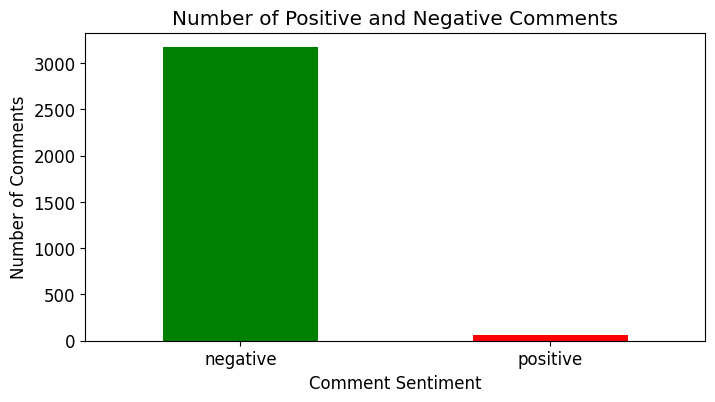

In [ ]:
# Visualize the number of positive and negative comments
comment_counts = df['predictions'].value_counts()
plt.figure(figsize=(8, 4))
comment_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Number of Positive and Negative Comments')
plt.xlabel('Comment Sentiment')
plt.ylabel('Number of Comments')
plt.xticks(rotation=0)
plt.show()

In [ ]:
#Analyzing common reasons for negative comments
negative_comments = df[df['predictions'] == 'negative']['cleaned_comment']

In [ ]:
negative_comments_text = ' '.join(negative_comments)

In [ ]:
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_comments_text)

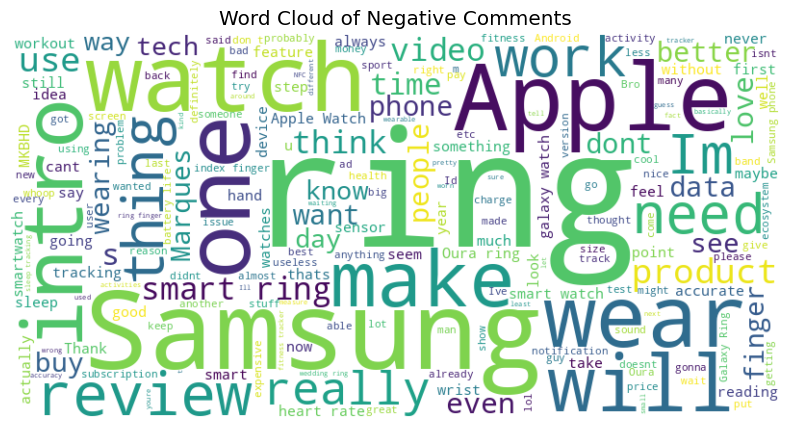

In [ ]:
#Displaying the word cloud for negative comments
plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Negative Comments')
plt.show()

In [ ]:
#Finding the most common words in negative comments
negative_word_counts = Counter(negative_comments_text.split())

In [ ]:
most_common_negative_words = negative_word_counts.most_common(10)
print("Most common words in negative comments:", most_common_negative_words)

Most common words in negative comments: [('the', 2617), ('a', 1912), ('to', 1599), ('I', 1369), ('it', 1277), ('and', 1158), ('ring', 1133), ('is', 917), ('for', 890), ('you', 846)]


In [ ]:
#Ensuring no empty comments are present
negative_comments = negative_comments[negative_comments.str.strip() != '']

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
#Performing LDA topic modeling
vectorizer = CountVectorizer(max_df=0.95, min_df=2)
dtm = vectorizer.fit_transform(negative_comments)

In [ ]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

LatentDirichletAllocation(n_components=5, random_state=42)

In [ ]:
#Function to display topics with full sentences
def display_topics_with_comments(model, feature_names, no_top_words, comments, dtm):
    topics_comments = {}
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        topic_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(" ".join(topic_words))
        topic_comments = []
        for idx, topic_dist in enumerate(model.transform(dtm)):
            if topic_dist[topic_idx] > 0.5:  # threshold to get comments for the topic
                topic_comments.append(comments.iloc[idx])
        topics_comments[topic_idx] = topic_comments[:5]  # get top 5 comments for the topic
        print("\n".join(topic_comments[:5]))
        print("\n")
    return topics_comments

no_top_words = 10
topics_comments = display_topics_with_comments(lda, vectorizer.get_feature_names_out(), no_top_words, df[df['predictions'] == 'negative']['comment'], dtm)

Topic 0:
the it to and for is you that ring like
For that price… this is the biggest bs I’ve ever seen. Why should I buy ring instead of an actual smartwatch? Smartwatch can do even more, even better for less money. You can even pay with NFC on a watch. Smart ring on aliexpress costs 15 bucks and I’m going to try it. I bet it will be the same stupid thing, without titanium and 450 dollar pricetag.
Apple will do it right and release theirs in 5 years time
The pricing on these is terrible and I expect these to be DoA. These shouldve been under 100-200$.
Jeweler here: there's a size difference between your left and right hand, depending on which hand is your dominant hand. The difference can range between half a size to a full size!!! Maybe that's where you made the mistake
Very overpriced for a minescuale amount of sensors


Topic 1:
intro that it the was is in mkbhd review love
I looked at other reviews and only yours seems to be negative. Now I am wondering whether your experience is o